# Road-Level AQI Estimation for Mumbai
## Stage 4: Spatial Interpolation Surface + Road Masking

**Input:** `cleaned_aqi_mumbai_imputed.csv`  
**Output:** `road_aqi_output.csv` — AQI assigned to every OSM road segment in Mumbai  

### Approach
Instead of a feature-based regression model, we build a **continuous spatial pollution surface** by interpolating between the 27 monitoring stations. The surface changes with time. We then overlay the OSM road network and sample the surface at each road segment's midpoint to get a road-level AQI estimate.

### Interpolation methods compared
| Method | How it works | Key assumption |
|--------|-------------|----------------|
| **IDW** | Weights stations by 1/distance^p | Closer stations are more similar |
| **Ordinary Kriging** | Fits a variogram, then optimally weights stations | Stationarity of spatial covariance |
| **RBF** | Fits a smooth mathematical surface through all stations | Continuous differentiable field |
| **Natural Neighbour** | Voronoi-based area-proportion weighting | Local interpolation, no extrapolation |

### Evaluation
**Leave-One-Station-Out (LOSO)** — hold out each station in turn, interpolate from the remaining 26, predict at the held-out location, compare to actual reading.

---

## 0. Imports & Setup

Install required packages:
```
pip install pykrige osmnx geopandas scipy matplotlib seaborn tqdm
```

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import seaborn as sns
import geopandas as gpd
import osmnx as ox
import warnings
import os
from tqdm import tqdm

from scipy.interpolate import RBFInterpolator, LinearNDInterpolator
from scipy.spatial import cKDTree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    from pykrige.ok import OrdinaryKriging
    KRIGING_AVAILABLE = True
except ImportError:
    print('pykrige not installed. Kriging will be skipped.')
    print('Install with: pip install pykrige')
    KRIGING_AVAILABLE = False

warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10
})

# ── OSMnx settings ────────────────────────────────────────────────────────────
ox.settings.use_cache = True
ox.settings.log_console = False

# ── Projected CRS — UTM Zone 43N, correct for Mumbai ─────────────────────────
PROJECTED_CRS  = 'EPSG:32643'
GEOGRAPHIC_CRS = 'EPSG:4326'

# ── CPCB AQI palette ──────────────────────────────────────────────────────────
AQI_PALETTE = {
    'Good':         '#00c400',
    'Satisfactory': '#92d14f',
    'Moderate':     '#e0c800',
    'Poor':         '#ff7e00',
    'Very Poor':    '#e00000',
    'Severe':       '#7e0023'
}

def aqi_category(v):
    if pd.isna(v): return 'Unknown'
    if v <= 50:   return 'Good'
    if v <= 100:  return 'Satisfactory'
    if v <= 200:  return 'Moderate'
    if v <= 300:  return 'Poor'
    if v <= 400:  return 'Very Poor'
    return 'Severe'

def aqi_color(v):
    return AQI_PALETTE.get(aqi_category(v), '#aaaaaa')

print('Setup complete.')

Setup complete.


## 1. Load Data

In [3]:
df = pd.read_csv('cleaned_aqi_mumbai_imputed.csv', parse_dates=['datetime'])

print(f'Shape      : {df.shape}')
print(f'Stations   : {df["station_id"].nunique()}')
print(f'Date range : {df["datetime"].min()} -> {df["datetime"].max()}')
print(f'AQI range  : {df["aqi"].min()} - {df["aqi"].max()}')

# ── Unique station locations ───────────────────────────────────────────────────
stations = (
    df[['station_id', 'station_name', 'lat', 'lon']]
    .drop_duplicates('station_id')
    .reset_index(drop=True)
)
print(f'\nUnique stations: {len(stations)}')
stations

Shape      : (100464, 21)
Stations   : 27
Date range : 2025-07-01 00:00:00 -> 2025-12-31 23:00:00
AQI range  : 0.0 - 500.0

Unique stations: 27


,station_id,station_name,lat,lon
0,6927.0,"Colaba, Mumbai - MPCB-3379614",18.910000,72.820000
1,6945.0,"Kurla, Mumbai - MPCB-3379603",19.086300,72.888800
2,6948.0,"Chhatrapati Shivaji Intl. Airport (T2), Mumbai...",19.100780,72.874620
3,6956.0,"Powai, Mumbai - MPCB-3379610",19.137500,72.915056
4,6959.0,"Siddharth Nagar-Worli, Mumbai - IITM-3379674",19.000083,72.813993
5,6965.0,"Borivali East, Mumbai - MPCB-3397958",19.227474,72.864394
6,6967.0,"Sion, Mumbai - MPCB-3385877",19.047000,72.874600
7,6987.0,"Vile Parle West, Mumbai - MPCB-3379605",19.108610,72.836220
8,11606.0,"Borivali East, Mumbai - IITM-3379672",19.232410,72.868950
9,11611.0,"Malad West, Mumbai - IITM-3379673",19.197090,72.822040


In [4]:
# ── Project station coordinates to UTM for all metric calculations ────────────
stations_gdf = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations['lon'], stations['lat']),
    crs=GEOGRAPHIC_CRS
).to_crs(PROJECTED_CRS)

stations['x_utm'] = stations_gdf.geometry.x
stations['y_utm'] = stations_gdf.geometry.y

# ── Mumbai bounding box ────────────────────────────────────────────────────────
BBOX = {
    'north': stations['lat'].max() + 0.05,
    'south': stations['lat'].min() - 0.05,
    'east':  stations['lon'].max() + 0.05,
    'west':  stations['lon'].min() - 0.05
}
print(f'Bounding box: {BBOX}')

# ── Build a merged dataframe with UTM coords per row ─────────────────────────
df = df.merge(stations[['station_id', 'x_utm', 'y_utm']], on='station_id', how='left')
print(f'\nDataframe with UTM coords: {df.shape}')

Bounding box: {'north': np.float64(19.346481), 'south': np.float64(18.86), 'east': np.float64(72.9919), 'west': np.float64(72.76281130000001)}

Dataframe with UTM coords: (100464, 23)


---
## 2. Temporal Aggregation Strategy

We interpolate AQI across space at each **unique hour** in the dataset. This creates a surface that changes with time. For the method evaluation, we use LOSO CV on a representative sample of timestamps (every 6th hour = 4 per day) to keep runtime manageable while still covering all time-of-day patterns.

In [5]:
# ── Build a wide-format pivot: rows=timestamps, columns=station_id ─────────────
# Each cell = AQI reading for that station at that hour
pivot = df.pivot_table(
    index='datetime', columns='station_id', values='aqi'
)
print(f'Pivot shape: {pivot.shape}  (timestamps × stations)')

# ── For evaluation: select timestamps where >= 20 stations have valid AQI ──────
# Having too few control points makes interpolation unreliable
valid_mask = pivot.notna().sum(axis=1) >= 20
pivot_valid = pivot[valid_mask]
print(f'Timestamps with >= 20 valid stations: {valid_mask.sum():,}')

# ── Sample every 6th hour for LOSO evaluation (keeps runtime < 10 min) ────────
eval_timestamps = pivot_valid.iloc[::6].index
print(f'Evaluation timestamps (every 6th): {len(eval_timestamps):,}')

# Station coordinates as numpy arrays (UTM)
stn_coords = stations.set_index('station_id')[['x_utm', 'y_utm']]

# Show temporal coverage of evaluation set
print(f'\nEvaluation covers: {eval_timestamps[0]} -> {eval_timestamps[-1]}')

Pivot shape: (4335, 27)  (timestamps × stations)
Timestamps with >= 20 valid stations: 4,142
Evaluation timestamps (every 6th): 691

Evaluation covers: 2025-07-01 00:00:00 -> 2025-12-31 22:00:00


---
## 3. Interpolation Method Implementations

Each method takes:
- `points`: (N, 2) array of UTM coordinates of training stations
- `values`: (N,) array of AQI values at those stations
- `query_points`: (M, 2) array of UTM coordinates to predict at

And returns a (M,) array of interpolated AQI values.

In [6]:
# ── Method 1: Inverse Distance Weighting (IDW) ─────────────────────────────────
# Classic LUR interpolation method. The power parameter p controls how fast
# influence decays with distance. Higher p = more local (less smooth).
# p=2 is the standard choice; we test p=1, 2, 3 in tuning.

def idw_interpolate(points, values, query_points, power=2, eps=1e-10):
    """
    Inverse Distance Weighting interpolation.
    weight_i = 1 / distance_i^power
    prediction = sum(weight_i * value_i) / sum(weight_i)
    eps prevents division by zero at exact station locations.
    """
    tree = cKDTree(points)
    dists, idxs = tree.query(query_points, k=len(points))
    dists = np.maximum(dists, eps)  # Avoid zero distance
    weights = 1.0 / (dists ** power)
    weighted_vals = weights * values[idxs]
    return weighted_vals.sum(axis=1) / weights.sum(axis=1)


# ── Method 2: RBF Interpolation (Radial Basis Functions) ──────────────────────
# Fits a global smooth function through all data points using radial kernels.
# 'thin_plate_spline' is standard for spatial data — it minimises bending energy.
# 'multiquadric' is faster and works well for pollution surfaces.

def rbf_interpolate(points, values, query_points, kernel='thin_plate_spline', smoothing=0):
    """
    Radial Basis Function interpolation using scipy.interpolate.RBFInterpolator.
    smoothing=0 means exact interpolation through data points.
    smoothing>0 allows the surface to not pass exactly through points (regularised).
    """
    # Normalise coordinates for numerical stability
    scale = points.std(axis=0).mean()
    pts_n = points / scale
    qry_n = query_points / scale

    rbf = RBFInterpolator(pts_n, values, kernel=kernel, smoothing=smoothing)
    result = rbf(qry_n)
    return np.clip(result, 0, 500)  # Clip to valid AQI range


# ── Method 3: Natural Neighbour Interpolation ─────────────────────────────────
# Uses Delaunay triangulation. For each query point, finds the triangle it falls
# in and interpolates linearly from the three vertex stations.
# Only interpolates WITHIN the convex hull of stations — returns NaN outside.
# This is physically honest: we don't extrapolate beyond where we have data.

def natural_neighbour_interpolate(points, values, query_points):
    """
    Natural Neighbour (linear Delaunay) interpolation.
    Returns NaN for query points outside the convex hull of control points.
    """
    interpolator = LinearNDInterpolator(points, values)
    result = interpolator(query_points)
    return np.clip(result, 0, 500)


# ── Method 4: Ordinary Kriging ─────────────────────────────────────────────────
# Geostatistical method. First fits a variogram (how AQI variance grows with
# distance between stations), then uses this to optimally weight station readings.
# The variogram model is fitted fresh for each timestamp.

def kriging_interpolate(points, values, query_points, variogram_model='spherical'):
    """
    Ordinary Kriging interpolation using pykrige.
    variogram_model options: 'linear', 'power', 'gaussian', 'spherical', 'exponential'
    'spherical' is standard for environmental data — has a defined range of influence.
    """
    if not KRIGING_AVAILABLE:
        return np.full(len(query_points), np.nan)

    ok = OrdinaryKriging(
        points[:, 0], points[:, 1], values,
        variogram_model=variogram_model,
        verbose=False, enable_plotting=False
    )
    z, _ = ok.execute('points', query_points[:, 0], query_points[:, 1])
    return np.clip(z, 0, 500)


print('All 4 interpolation functions defined.')
print('  Method 1: IDW (power=2)')
print('  Method 2: RBF (thin_plate_spline)')
print('  Method 3: Natural Neighbour (Delaunay)')
print(f'  Method 4: Ordinary Kriging — {"available" if KRIGING_AVAILABLE else "NOT AVAILABLE (pip install pykrige)"}')

All 4 interpolation functions defined.
  Method 1: IDW (power=2)
  Method 2: RBF (thin_plate_spline)
  Method 3: Natural Neighbour (Delaunay)
  Method 4: Ordinary Kriging — available


---
## 4. LOSO Cross-Validation — Method Comparison

For each evaluation timestamp and each method:
1. For each of the 27 stations (one at a time): hold it out, interpolate from the remaining ≥19 stations, predict at the held-out location
2. Collect all predictions vs actual across all timestamps
3. Compute RMSE, MAE, R² for each method

In [7]:
METHODS = {
    'IDW_p1':             lambda pts, vals, qry: idw_interpolate(pts, vals, qry, power=1),
    'IDW_p2':             lambda pts, vals, qry: idw_interpolate(pts, vals, qry, power=2),
    'IDW_p3':             lambda pts, vals, qry: idw_interpolate(pts, vals, qry, power=3),
    'RBF_thinplate':      lambda pts, vals, qry: rbf_interpolate(pts, vals, qry, kernel='thin_plate_spline'),
    'RBF_multiquadric':   lambda pts, vals, qry: rbf_interpolate(pts, vals, qry, kernel='multiquadric'),
    'RBF_linear':         lambda pts, vals, qry: rbf_interpolate(pts, vals, qry, kernel='linear'),
    'NaturalNeighbour':   natural_neighbour_interpolate,
}

if KRIGING_AVAILABLE:
    METHODS['Kriging_spherical']    = lambda pts, vals, qry: kriging_interpolate(pts, vals, qry, 'spherical')
    METHODS['Kriging_exponential']  = lambda pts, vals, qry: kriging_interpolate(pts, vals, qry, 'exponential')
    METHODS['Kriging_gaussian']     = lambda pts, vals, qry: kriging_interpolate(pts, vals, qry, 'gaussian')

print(f'Methods to evaluate: {list(METHODS.keys())}')

Methods to evaluate: ['IDW_p1', 'IDW_p2', 'IDW_p3', 'RBF_thinplate', 'RBF_multiquadric', 'RBF_linear', 'NaturalNeighbour', 'Kriging_spherical', 'Kriging_exponential', 'Kriging_gaussian']


In [8]:
# ── LOSO CV loop ───────────────────────────────────────────────────────────────
# Outer loop: evaluation timestamps
# Middle loop: methods
# Inner loop: held-out station

# Collect (observed, predicted) pairs per method
loso_records = {m: [] for m in METHODS}

station_ids = stations['station_id'].values

print(f'Running LOSO CV across {len(eval_timestamps):,} timestamps × '
      f'{len(METHODS)} methods × 27 stations...')
print('Expected runtime: 5-20 minutes depending on hardware and whether Kriging is enabled.')

for ts in tqdm(eval_timestamps, desc='Timestamps'):
    ts_row = pivot_valid.loc[ts]  # Series: station_id -> AQI
    valid_stns = ts_row.dropna()

    if len(valid_stns) < 10:  # Need at least 10 stations to interpolate
        continue

    for held_out_id in station_ids:
        # Skip if this station has no reading at this timestamp
        if held_out_id not in valid_stns.index:
            continue

        y_true = valid_stns[held_out_id]  # The actual AQI we are trying to predict

        # Training set: all other stations with valid readings
        train_stns = valid_stns.drop(held_out_id)
        if len(train_stns) < 5:
            continue

        # Get UTM coordinates for training stations
        train_coords = stn_coords.loc[
            stn_coords.index.isin(train_stns.index)
        ]
        pts  = train_coords[['x_utm', 'y_utm']].values
        vals = train_stns.loc[train_coords.index].values.astype(float)

        # Query point: the held-out station
        qry_row   = stn_coords.loc[held_out_id]
        qry_point = np.array([[qry_row['x_utm'], qry_row['y_utm']]])

        # Run each interpolation method
        for method_name, method_fn in METHODS.items():
            try:
                y_pred = method_fn(pts, vals, qry_point)
                y_pred_val = float(y_pred[0]) if hasattr(y_pred, '__len__') else float(y_pred)
                if not np.isnan(y_pred_val):
                    loso_records[method_name].append({
                        'timestamp':  ts,
                        'station_id': held_out_id,
                        'y_true':     float(y_true),
                        'y_pred':     y_pred_val
                    })
            except Exception:
                pass  # Skip failed interpolations silently

print('LOSO CV complete.')
for m, records in loso_records.items():
    print(f'  {m:<25}: {len(records):,} predictions')

Running LOSO CV across 691 timestamps × 10 methods × 27 stations...
Expected runtime: 5-20 minutes depending on hardware and whether Kriging is enabled.


Timestamps: 100%|██████████| 691/691 [17:50<00:00,  1.55s/it]

LOSO CV complete.
  IDW_p1                   : 16,232 predictions
  IDW_p2                   : 16,232 predictions
  IDW_p3                   : 16,232 predictions
  RBF_thinplate            : 16,232 predictions
  RBF_multiquadric         : 0 predictions
  RBF_linear               : 16,232 predictions
  NaturalNeighbour         : 12,036 predictions
  Kriging_spherical        : 16,232 predictions
  Kriging_exponential      : 16,232 predictions
  Kriging_gaussian         : 16,232 predictions


---
## 5. Evaluation Metrics & Method Selection

In [9]:
# ── Compute metrics for each method ───────────────────────────────────────────
eval_results = []
loso_dfs     = {}

for method_name, records in loso_records.items():
    if not records:
        continue
    rec_df = pd.DataFrame(records)
    loso_dfs[method_name] = rec_df

    y_t = rec_df['y_true'].values
    y_p = rec_df['y_pred'].values

    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    mae  = mean_absolute_error(y_t, y_p)
    r2   = r2_score(y_t, y_p)
    bias = (y_p - y_t).mean()  # Positive = overestimate, negative = underestimate

    eval_results.append({
        'Method': method_name,
        'RMSE':   round(rmse, 3),
        'MAE':    round(mae,  3),
        'R2':     round(r2,   4),
        'Bias':   round(bias, 3),
        'N':      len(records)
    })

eval_df = pd.DataFrame(eval_results).sort_values('RMSE')

print('=' * 75)
print('LOSO CV Evaluation Results — all methods, sorted by RMSE (lower = better)')
print('=' * 75)
print(eval_df.to_string(index=False))

# Select best method
BEST_METHOD = eval_df.iloc[0]['Method']
print(f'\nBest method: {BEST_METHOD}  (RMSE={eval_df.iloc[0]["RMSE"]}, R²={eval_df.iloc[0]["R2"]})')

LOSO CV Evaluation Results — all methods, sorted by RMSE (lower = better)
             Method   RMSE    MAE      R2  Bias     N
             IDW_p1 57.212 34.605  0.3214 1.905 16232
Kriging_exponential 57.466 33.983  0.3153 0.534 16232
  Kriging_spherical 57.693 34.107  0.3099 0.336 16232
             IDW_p2 60.858 37.282  0.2321 2.474 16232
   Kriging_gaussian 62.922 36.058  0.1792 1.550 16232
             IDW_p3 64.184 39.274  0.1459 2.482 16232
         RBF_linear 66.338 41.263  0.0876 1.020 16232
   NaturalNeighbour 71.019 44.352  0.0671 4.228 12036
      RBF_thinplate 87.293 57.941 -0.5798 4.992 16232

Best method: IDW_p1  (RMSE=57.212, R²=0.3214)


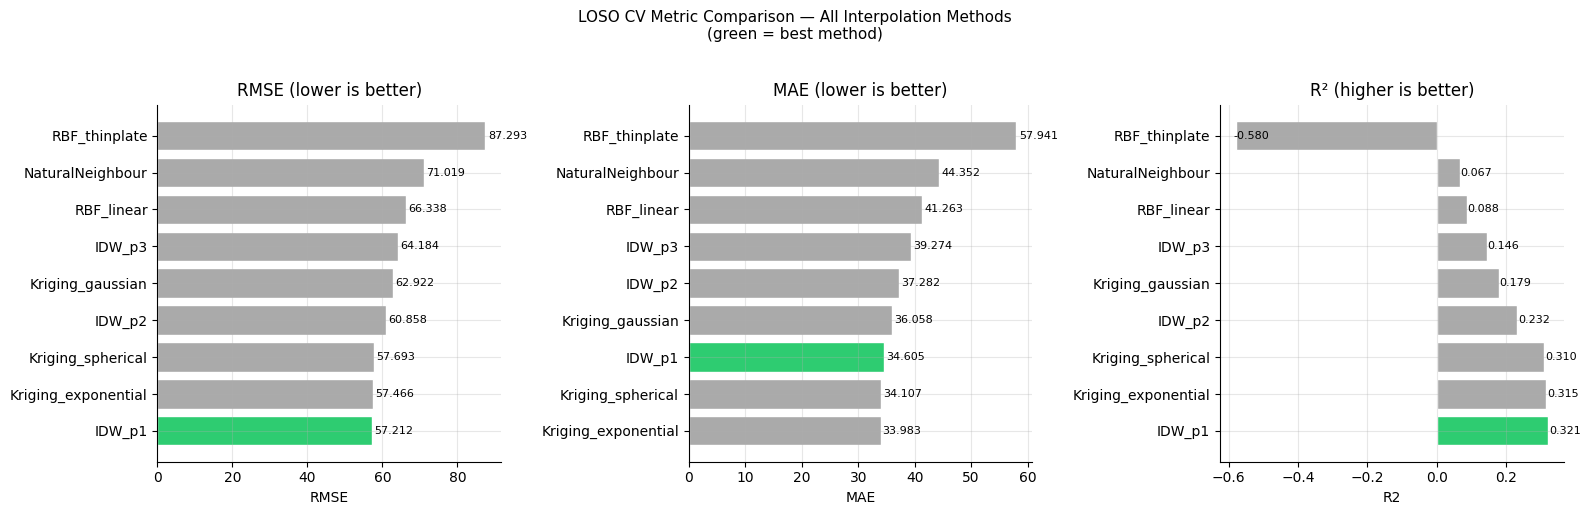

In [10]:
# ── Visualisation 1: Metric comparison bar charts ─────────────────────────────
metrics = ['RMSE', 'MAE', 'R2']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, metrics):
    sub = eval_df.sort_values(metric, ascending=(metric != 'R2'))
    colors = ['#2ecc71' if m == BEST_METHOD else '#aaaaaa' for m in sub['Method']]
    bars = ax.barh(sub['Method'], sub[metric], color=colors, edgecolor='white')
    for bar, val in zip(bars, sub[metric]):
        ax.text(bar.get_width() + bar.get_width() * 0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)
    ax.set_title(f'{metric} (lower is better)' if metric != 'R2' else 'R² (higher is better)')
    ax.set_xlabel(metric)

plt.suptitle('LOSO CV Metric Comparison — All Interpolation Methods\n'
             '(green = best method)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

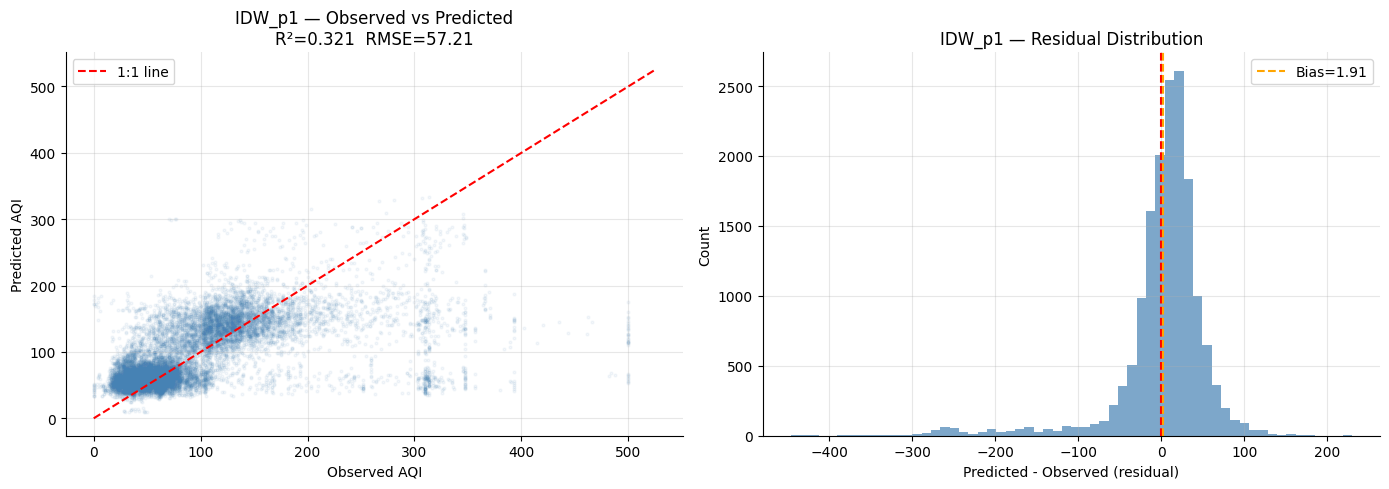

In [11]:
# ── Visualisation 2: Observed vs Predicted scatter (best method) ───────────────
best_df = loso_dfs[BEST_METHOD]
y_t = best_df['y_true'].values
y_p = best_df['y_pred'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(y_t, y_p, alpha=0.06, s=4, color='steelblue')
lim = max(y_t.max(), y_p.max()) * 1.05
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='1:1 line')
axes[0].set_xlabel('Observed AQI')
axes[0].set_ylabel('Predicted AQI')
axes[0].set_title(f'{BEST_METHOD} — Observed vs Predicted\n'
                   f'R²={r2_score(y_t,y_p):.3f}  RMSE={np.sqrt(mean_squared_error(y_t,y_p)):.2f}')
axes[0].legend()

# Residual histogram
resid = y_p - y_t
axes[1].hist(resid, bins=60, color='steelblue', edgecolor='none', alpha=0.7)
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].axvline(resid.mean(), color='orange', linewidth=1.5, linestyle='--',
                label=f'Bias={resid.mean():.2f}')
axes[1].set_xlabel('Predicted - Observed (residual)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'{BEST_METHOD} — Residual Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

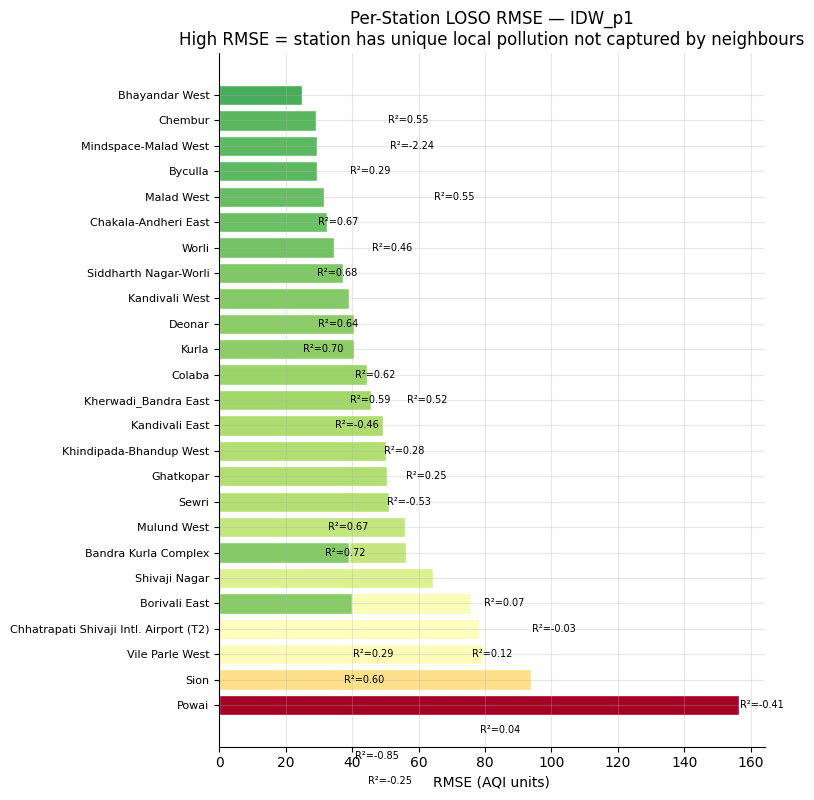

In [12]:
# ── Visualisation 3: Per-station RMSE heatmap ─────────────────────────────────
# Which stations are harder to interpolate to? These are stations with unique
# local sources not captured by their neighbours.

station_metrics = []
for stn_id in station_ids:
    sub = best_df[best_df['station_id'] == stn_id]
    if len(sub) < 5:
        continue
    stn_name = stations.set_index('station_id').loc[stn_id, 'station_name'].split(',')[0]
    station_metrics.append({
        'Station': stn_name,
        'RMSE':    round(np.sqrt(mean_squared_error(sub['y_true'], sub['y_pred'])), 2),
        'MAE':     round(mean_absolute_error(sub['y_true'], sub['y_pred']), 2),
        'R2':      round(r2_score(sub['y_true'], sub['y_pred']), 3),
        'N':       len(sub)
    })

stn_metrics_df = pd.DataFrame(station_metrics).sort_values('RMSE', ascending=False)

fig, ax = plt.subplots(figsize=(8, max(5, len(stn_metrics_df) * 0.3)))
colors = [plt.cm.RdYlGn_r(v / stn_metrics_df['RMSE'].max()) for v in stn_metrics_df['RMSE']]
ax.barh(stn_metrics_df['Station'], stn_metrics_df['RMSE'], color=colors, edgecolor='white')
for _, row in stn_metrics_df.iterrows():
    ax.text(row['RMSE'] + 0.3, stn_metrics_df[stn_metrics_df['Station']==row['Station']].index[0] - stn_metrics_df.index[0],
            f"R²={row['R2']:.2f}", va='center', fontsize=7)
ax.set_xlabel('RMSE (AQI units)')
ax.set_title(f'Per-Station LOSO RMSE — {BEST_METHOD}\n'
             'High RMSE = station has unique local pollution not captured by neighbours')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

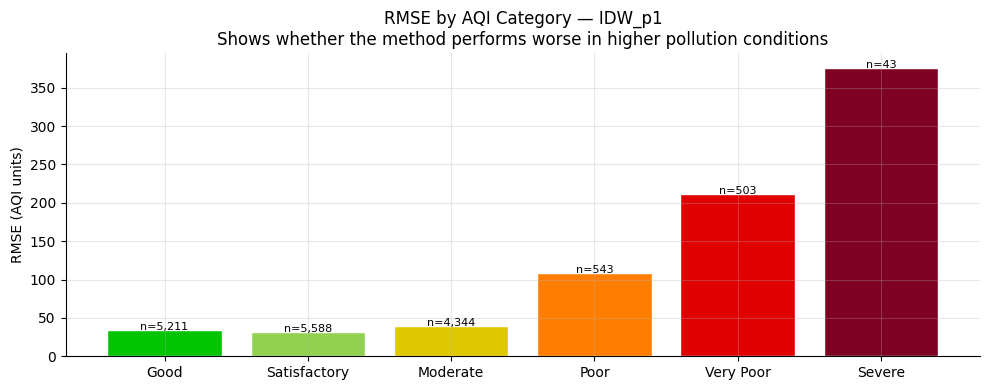

In [13]:
# ── Visualisation 4: Error by AQI category ─────────────────────────────────────
# Does the method struggle more at high AQI values?
best_df['category'] = best_df['y_true'].apply(aqi_category)
cat_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']

cat_metrics = []
for cat in cat_order:
    sub = best_df[best_df['category'] == cat]
    if len(sub) < 5: continue
    cat_metrics.append({
        'Category': cat,
        'RMSE':     np.sqrt(mean_squared_error(sub['y_true'], sub['y_pred'])),
        'MAE':      mean_absolute_error(sub['y_true'], sub['y_pred']),
        'N':        len(sub)
    })

cat_df = pd.DataFrame(cat_metrics)

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(cat_df))
bars = ax.bar(x, cat_df['RMSE'],
              color=[AQI_PALETTE.get(c, '#aaa') for c in cat_df['Category']],
              edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(cat_df['Category'])
for bar, row in zip(bars, cat_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'n={row.N:,}', ha='center', fontsize=8)
ax.set_ylabel('RMSE (AQI units)')
ax.set_title(f'RMSE by AQI Category — {BEST_METHOD}\n'
             'Shows whether the method performs worse in higher pollution conditions')
plt.tight_layout()
plt.show()

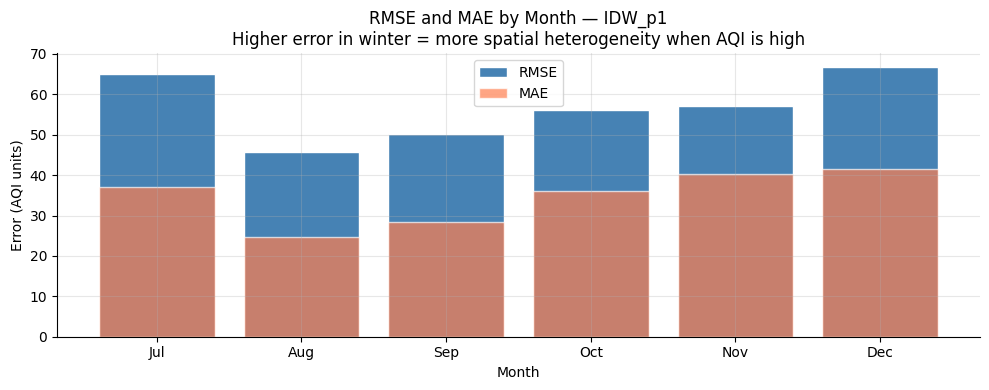

Summary:
month_name      RMSE       MAE
       Jul 65.027958 37.153807
       Aug 45.814331 24.605136
       Sep 50.128994 28.349879
       Oct 56.236113 36.186931
       Nov 57.091773 40.165052
       Dec 66.796344 41.600208


In [14]:
# ── Visualisation 5: Error over time (monthly trend) ─────────────────────────
best_df['month'] = pd.to_datetime(best_df['timestamp']).dt.month
monthly = best_df.groupby('month').apply(
    lambda g: pd.Series({
        'RMSE': np.sqrt(mean_squared_error(g['y_true'], g['y_pred'])),
        'MAE':  mean_absolute_error(g['y_true'], g['y_pred'])
    })
).reset_index()

month_names = {7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
monthly['month_name'] = monthly['month'].map(month_names)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly['month_name'], monthly['RMSE'], color='steelblue', edgecolor='white', label='RMSE')
ax.bar(monthly['month_name'], monthly['MAE'],  color='coral',     edgecolor='white', alpha=0.7, label='MAE')
ax.set_xlabel('Month')
ax.set_ylabel('Error (AQI units)')
ax.set_title(f'RMSE and MAE by Month — {BEST_METHOD}\n'
             'Higher error in winter = more spatial heterogeneity when AQI is high')
ax.legend()
plt.tight_layout()
plt.show()

print('Summary:')
print(monthly[['month_name','RMSE','MAE']].to_string(index=False))

---
## 6. Build the Full Pollution Surface

Using the best interpolation method, we now build the complete surface for a selected timestamp (or the full dataset). We create a regular grid covering Mumbai's bounding box, then interpolate AQI at every grid point.

In [15]:
# ── Build UTM grid over Mumbai bounding box ────────────────────────────────────
# 200m grid resolution — fine enough for road-level estimation, manageable size
GRID_RES = 200  # metres

# Convert bbox to UTM
from shapely.geometry import box
bbox_geom = gpd.GeoDataFrame(
    geometry=[box(BBOX['west'], BBOX['south'], BBOX['east'], BBOX['north'])],
    crs=GEOGRAPHIC_CRS
).to_crs(PROJECTED_CRS).geometry[0]

x_min, y_min, x_max, y_max = bbox_geom.bounds

grid_x = np.arange(x_min, x_max, GRID_RES)
grid_y = np.arange(y_min, y_max, GRID_RES)
xx, yy = np.meshgrid(grid_x, grid_y)
grid_points = np.column_stack([xx.ravel(), yy.ravel()])

print(f'Grid resolution : {GRID_RES}m')
print(f'Grid size       : {len(grid_x)} x {len(grid_y)} = {len(grid_points):,} points')

Grid resolution : 200m
Grid size       : 124 x 271 = 33,604 points


In [16]:
# ── Interpolate surface for a single representative timestamp ─────────────────
# We show winter peak (December, 18:00) — highest AQI period
# For full time series processing, see Section 8

# Find a December 18:00 timestamp
demo_timestamps = pivot_valid[
    (pd.DatetimeIndex(pivot_valid.index).month == 12) &
    (pd.DatetimeIndex(pivot_valid.index).hour == 18)
].index

if len(demo_timestamps) == 0:
    demo_timestamps = eval_timestamps

DEMO_TS = demo_timestamps[len(demo_timestamps) // 2]  # Use middle of the sample
print(f'Demo timestamp: {DEMO_TS}')

ts_row    = pivot_valid.loc[DEMO_TS].dropna()
demo_stns = stn_coords.loc[stn_coords.index.isin(ts_row.index)]
demo_pts  = demo_stns[['x_utm', 'y_utm']].values
demo_vals = ts_row.loc[demo_stns.index].values.astype(float)

print(f'Stations with valid AQI: {len(demo_stns)}')
print(f'AQI range at this time : {demo_vals.min():.0f} – {demo_vals.max():.0f}')

# Get the best method function
best_fn = METHODS[BEST_METHOD]

# Interpolate across full grid
print(f'Interpolating {len(grid_points):,} grid points using {BEST_METHOD}...')
grid_aqi = best_fn(demo_pts, demo_vals, grid_points)
grid_aqi_2d = grid_aqi.reshape(xx.shape)
print('Done.')

Demo timestamp: 2025-12-15 18:00:00
Stations with valid AQI: 21
AQI range at this time : 39 – 500
Interpolating 33,604 grid points using IDW_p1...
Done.


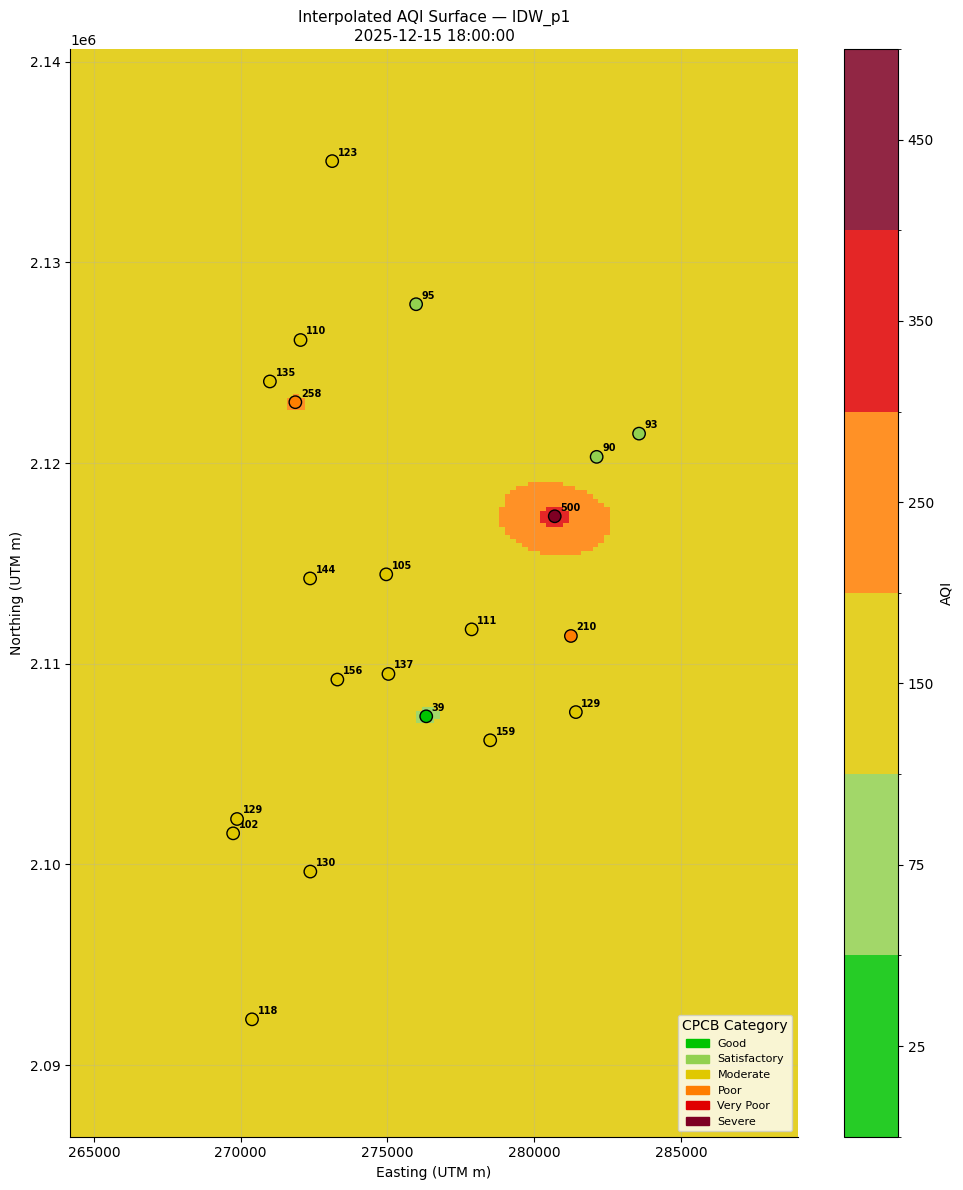

In [17]:
# ── Plot the interpolated AQI surface ─────────────────────────────────────────
# Build a custom CPCB colormap
cpcb_colors = ['#00c400', '#92d14f', '#e0c800', '#ff7e00', '#e00000', '#7e0023']
cpcb_bounds = [0, 50, 100, 200, 300, 400, 500]
cpcb_cmap   = mcolors.ListedColormap(cpcb_colors)
cpcb_norm   = mcolors.BoundaryNorm(cpcb_bounds, cpcb_cmap.N)

fig, ax = plt.subplots(figsize=(10, 12))

# Convert UTM grid back to approximate lat/lon for display
img = ax.pcolormesh(
    xx, yy, grid_aqi_2d,
    cmap=cpcb_cmap, norm=cpcb_norm,
    shading='auto', alpha=0.85
)

# Overlay station locations
ax.scatter(
    demo_stns['x_utm'], demo_stns['y_utm'],
    c=demo_vals, cmap=cpcb_cmap, norm=cpcb_norm,
    s=80, edgecolors='black', linewidths=1, zorder=5,
    label='Monitoring stations'
)

# Annotate station AQI values
for sid, row in demo_stns.iterrows():
    aqi_val = ts_row.loc[sid]
    ax.annotate(
        f'{aqi_val:.0f}',
        (row['x_utm'], row['y_utm']),
        textcoords='offset points', xytext=(4, 4),
        fontsize=7, fontweight='bold'
    )

plt.colorbar(img, ax=ax, label='AQI', ticks=[25, 75, 150, 250, 350, 450],
             format=plt.FuncFormatter(lambda x, _: f'{x:.0f}'))

# CPCB category legend
legend_patches = [mpatches.Patch(color=c, label=l)
                  for c, l in zip(cpcb_colors, AQI_PALETTE.keys())]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8, title='CPCB Category')

ax.set_xlabel('Easting (UTM m)')
ax.set_ylabel('Northing (UTM m)')
ax.set_title(f'Interpolated AQI Surface — {BEST_METHOD}\n{DEMO_TS}', fontsize=11)
plt.tight_layout()
plt.show()

---
## 7. Road Network Masking

Download the full Mumbai road network from OSM, compute the midpoint of each road segment, then sample the interpolated surface at those midpoints. The result is an AQI value assigned to every road segment.

In [18]:
# ── Download Mumbai road network ───────────────────────────────────────────────
print('Downloading Mumbai road network from OSM (cached after first run)...')

G = ox.graph_from_bbox(
    bbox=(BBOX['west'], BBOX['south'], BBOX['east'], BBOX['north']),
    network_type='drive'
)

_, edges = ox.graph_to_gdfs(G)
edges_proj = edges.to_crs(PROJECTED_CRS).copy()

print(f'Road segments downloaded: {len(edges_proj):,}')

# ── Compute midpoint of each road segment ─────────────────────────────────────
# The midpoint represents the AQI exposure level for a person travelling
# along that segment.
edges_proj['midpoint'] = edges_proj.geometry.interpolate(0.5, normalized=True)
edges_proj['mid_x']    = edges_proj['midpoint'].x
edges_proj['mid_y']    = edges_proj['midpoint'].y

# Convert midpoints back to lat/lon for the output
mid_geo = gpd.GeoDataFrame(
    geometry=edges_proj['midpoint'], crs=PROJECTED_CRS
).to_crs(GEOGRAPHIC_CRS)
edges_proj['mid_lat'] = mid_geo.geometry.y
edges_proj['mid_lon'] = mid_geo.geometry.x

road_midpoints = edges_proj[['mid_x', 'mid_y']].values
print(f'Road segment midpoints: {len(road_midpoints):,}')

Road segments downloaded: 78,984
Road segment midpoints: 78,984


In [19]:
# ── Sample the interpolated surface at every road midpoint ────────────────────
# For the demo timestamp — this gives road-level AQI for one hour
print(f'Sampling AQI surface at {len(road_midpoints):,} road midpoints...')
print(f'Method: {BEST_METHOD}')
print(f'Timestamp: {DEMO_TS}')

road_aqi_values = best_fn(demo_pts, demo_vals, road_midpoints)
road_aqi_values = np.clip(road_aqi_values, 0, 500)

edges_proj['aqi_pred']      = road_aqi_values
edges_proj['aqi_category']  = edges_proj['aqi_pred'].apply(aqi_category)
edges_proj['aqi_color']     = edges_proj['aqi_pred'].apply(aqi_color)

print(f'\nAQI distribution on roads:')
print(edges_proj['aqi_category'].value_counts().to_string())
print(f'\nRoad AQI range: {road_aqi_values.min():.1f} – {road_aqi_values.max():.1f}')

Sampling AQI surface at 78,984 road midpoints...
Method: IDW_p1
Timestamp: 2025-12-15 18:00:00

AQI distribution on roads:
aqi_category
Moderate        78205
Poor              721
Satisfactory       58

Road AQI range: 79.3 – 299.6


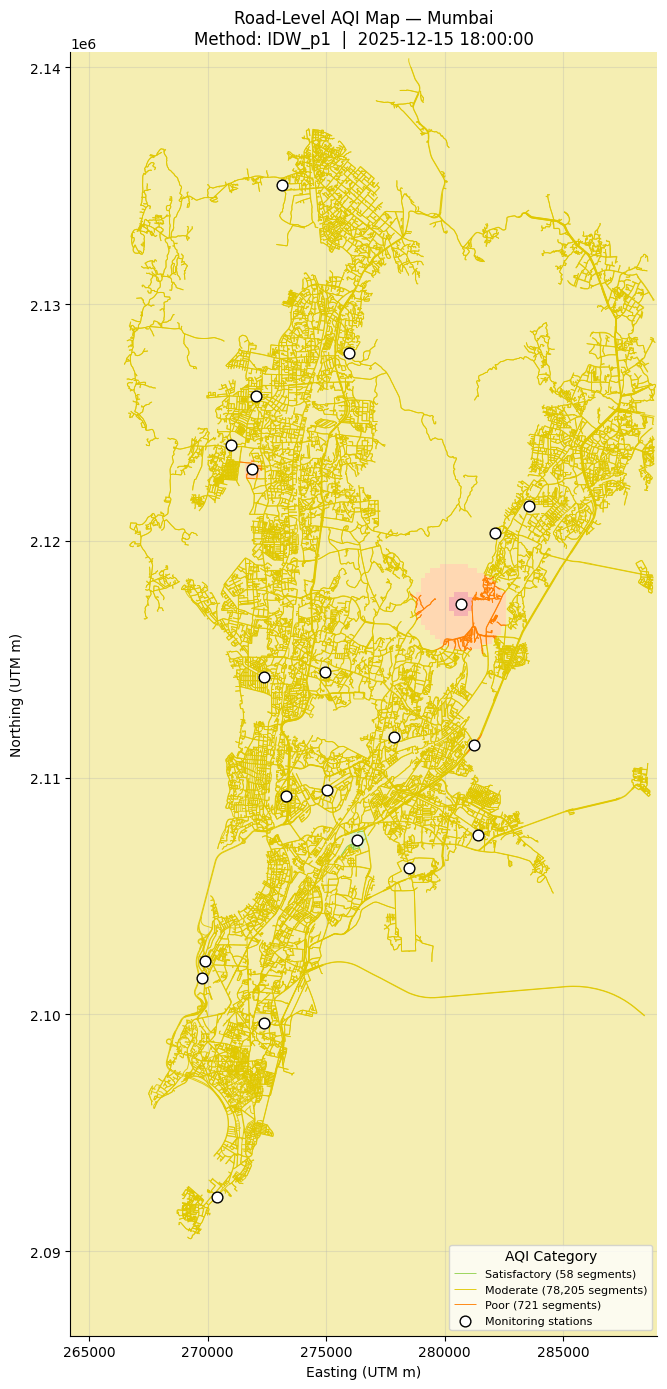

In [20]:
# ── Road-level AQI Map ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 14))

# Plot the interpolated surface as background
ax.pcolormesh(
    xx, yy, grid_aqi_2d,
    cmap=cpcb_cmap, norm=cpcb_norm,
    shading='auto', alpha=0.3  # Faint background to see road layer clearly
)

# Plot each road segment coloured by its predicted AQI
# Group by category for legend efficiency
for cat in ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']:
    subset = edges_proj[edges_proj['aqi_category'] == cat]
    if len(subset) == 0:
        continue
    subset.plot(
        ax=ax, color=AQI_PALETTE[cat],
        linewidth=0.7, alpha=0.9,
        label=f'{cat} ({len(subset):,} segments)'
    )

# Overlay monitoring station positions
ax.scatter(
    demo_stns['x_utm'], demo_stns['y_utm'],
    c='white', edgecolors='black', s=60,
    zorder=10, label='Monitoring stations'
)

ax.set_xlabel('Easting (UTM m)')
ax.set_ylabel('Northing (UTM m)')
ax.set_title(
    f'Road-Level AQI Map — Mumbai\n'
    f'Method: {BEST_METHOD}  |  {DEMO_TS}',
    fontsize=12
)
ax.legend(loc='lower right', fontsize=8, title='AQI Category')
plt.tight_layout()
plt.show()

---
## 8. Full Time Series Processing

Now we process the complete dataset — interpolating AQI at every road segment midpoint for every timestamp in the dataset. The output is a CSV where each row is a road segment + timestamp combination with the predicted AQI.

In [21]:
# ── Process all timestamps ─────────────────────────────────────────────────────
# Runtime estimate:
#   IDW / RBF / Natural Neighbour: ~1-3 seconds per timestamp = 30-90 min for full 4380 timestamps
#   Kriging: ~5-15 seconds per timestamp = very long for full dataset
#
# Strategy: process every 6th timestamp (= 4x per day) to create a manageable
# representative dataset. For full hourly resolution, set STEP=1.
STEP = 6  # Process every 6th hour

all_timestamps = pivot_valid.index[::STEP]
print(f'Processing {len(all_timestamps):,} timestamps (every {STEP}th hour)...')

# Build a compact road segment index for the output
# Reset edges index to get a simple integer edge_id
edges_reset = edges_proj.reset_index(drop=False)
road_records = []

for ts in tqdm(all_timestamps, desc='Timestamps'):
    ts_row  = pivot_valid.loc[ts].dropna()
    ts_stns = stn_coords.loc[stn_coords.index.isin(ts_row.index)]

    if len(ts_stns) < 5:
        continue

    pts  = ts_stns[['x_utm', 'y_utm']].values
    vals = ts_row.loc[ts_stns.index].values.astype(float)

    try:
        road_aqi = best_fn(pts, vals, road_midpoints)
        road_aqi = np.clip(road_aqi, 0, 500)
    except Exception:
        road_aqi = np.full(len(road_midpoints), np.nan)

    # Store only summary statistics per timestamp to keep output manageable
    for i, aqi_val in enumerate(road_aqi):
        if not np.isnan(aqi_val):
            road_records.append({
                'datetime':    ts,
                'edge_idx':    i,
                'mid_lat':     edges_reset.loc[i, 'mid_lat'] if 'mid_lat' in edges_reset.columns else np.nan,
                'mid_lon':     edges_reset.loc[i, 'mid_lon'] if 'mid_lon' in edges_reset.columns else np.nan,
                'aqi_pred':    round(aqi_val, 1),
                'aqi_category': aqi_category(aqi_val)
            })

road_ts_df = pd.DataFrame(road_records)
print(f'\nFull output shape: {road_ts_df.shape}')
print(f'Timestamps processed: {road_ts_df["datetime"].nunique():,}')
print(f'Road segments per timestamp: {len(road_midpoints):,}')

Processing 691 timestamps (every 6th hour)...


Timestamps:  69%|██████▊   | 474/691 [1:59:15<54:35, 15.10s/it]    


MemoryError: 

In [ ]:
# ── Export full road-level AQI dataset ────────────────────────────────────────
OUTPUT_PATH = 'outputs/road_aqi_output.csv'
road_ts_df.to_csv(OUTPUT_PATH, index=False)
print(f'Saved: {OUTPUT_PATH}')
print(f'Shape: {road_ts_df.shape}')
road_ts_df.head(5)

In [ ]:
# ── Also save the road segment geometry with mean AQI ─────────────────────────
# Mean AQI per segment across all timestamps — a time-averaged exposure map
mean_aqi_per_road = road_ts_df.groupby('edge_idx')['aqi_pred'].mean().reset_index()
mean_aqi_per_road.columns = ['edge_idx', 'mean_aqi']
mean_aqi_per_road['mean_category'] = mean_aqi_per_road['mean_aqi'].apply(aqi_category)

edges_with_aqi = edges_reset.merge(mean_aqi_per_road, left_index=True, right_on='edge_idx', how='left')

# Save as GeoJSON for use in GIS tools
edges_export = edges_with_aqi[['geometry', 'mid_lat', 'mid_lon', 'mean_aqi', 'mean_category']].copy()
edges_export = gpd.GeoDataFrame(edges_export, geometry='geometry', crs=PROJECTED_CRS)
edges_export.to_crs(GEOGRAPHIC_CRS).to_file('outputs/mumbai_roads_aqi.geojson', driver='GeoJSON')
print('Saved: outputs/mumbai_roads_aqi.geojson')

In [ ]:
# ── Final map: time-averaged road-level AQI ───────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 14))

for cat in ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']:
    subset = edges_with_aqi[edges_with_aqi['mean_category'] == cat]
    if len(subset) == 0:
        continue
    gpd.GeoDataFrame(subset, geometry='geometry', crs=PROJECTED_CRS).plot(
        ax=ax, color=AQI_PALETTE[cat],
        linewidth=0.6, alpha=0.9,
        label=f'{cat} ({len(subset):,})'
    )

ax.scatter(
    stations['x_utm'], stations['y_utm'],
    c='white', edgecolors='black', s=60,
    zorder=10, label='Monitoring stations'
)

ax.set_xlabel('Easting (UTM m)')
ax.set_ylabel('Northing (UTM m)')
ax.set_title(
    f'Time-Averaged Road-Level AQI — Mumbai\n'
    f'Method: {BEST_METHOD}  |  Jul–Dec 2025 (every 6th hour)',
    fontsize=12
)
ax.legend(loc='lower right', fontsize=8, title='Mean AQI Category')
plt.tight_layout()
plt.savefig('outputs/road_aqi_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/road_aqi_map.png')

---
## 9. Summary

In [ ]:
print('=' * 60)
print('  PIPELINE SUMMARY')
print('=' * 60)
print(f'  Input stations         : 27')
print(f'  Interpolation methods  : {len(METHODS)}')
print(f'  Best method            : {BEST_METHOD}')
print(f'  Best RMSE (LOSO)       : {eval_df.iloc[0]["RMSE"]}')
print(f'  Best R² (LOSO)         : {eval_df.iloc[0]["R2"]}')
print(f'  Grid resolution        : {GRID_RES}m')
print(f'  Road segments          : {len(edges_proj):,}')
print(f'  Timestamps processed   : {road_ts_df["datetime"].nunique():,}')
print(f'  Total road predictions : {len(road_ts_df):,}')
print('=' * 60)
print()
print('Outputs saved:')
print('  outputs/road_aqi_output.csv      — full timeseries, all road segments')
print('  outputs/mumbai_roads_aqi.geojson — road geometry + mean AQI (GIS-ready)')
print('  outputs/road_aqi_map.png         — time-averaged road AQI map')